In [5]:
import numpy as np
import matplotlib.pyplot as plt

def DBS(N, p, T, seed=None):
    if seed is not None:
        np.random.seed(seed)

    # Initial configuration
    X = np.random.binomial(1, p, size=N)

    zero_density = []

    for t in range(T):

        zeros = np.where(X == 0)[0]
        if len(zeros)>0:
            i = np.random.choice(zeros)
        else:
            i = np.random.randint(N)

        # Periodic boundary conditions: nearest neighbours on a ring
        left = (i - 1) % N
        right = (i + 1) % N

        # Bernoulli update step
        X[[left, i, right]] = np.random.binomial(1, p, size=3)
        
        # Fraction of sites in state 0
        zero_density.append(np.mean(X == 0))

    return zero_density

In [ ]:
# Bernoulli parameter values
p_values = [0.0005, 0.001, 0.002]

# System size and number of updates
N = 10000
T = 1000000

# Burn-in period used to approximate stationary regime
burn_in = 20000

plt.figure(figsize=(12,6))

print(f"For N={N} and {T} updating steps:")

for p in p_values:
    zero_density = DBS(N, p, T)

    plt.plot(zero_density, label=f"p={p}")

    # Estimate stationary density
    stationary_density = np.mean(zero_density[burn_in:])
    print(f"Stationary density of zeros for p={p}: {stationary_density}")

plt.xlabel("Time")
plt.ylabel("Fraction of zeros")
plt.title("Discrete model dynamics")
plt.legend()
plt.show()

For N=10000 and 1000000 updating steps:
Stationary density of zeros for p=0.0005: 0.9992407248979592


For N=10000 and 1000000 updating steps:
Stationary density of zeros for p=0.3: 0.48161064581632657
Stationary density of zeros for p=0.35: 0.32137828979591837
Stationary density of zeros for p=0.4: 0.03874957244897959
Stationary density of zeros for p=0.45: 0.007682237448979592
Stationary density of zeros for p=0.5: 0.001592234081632653
Stationary density of zeros for p=0.55: 0.00024764653061224486


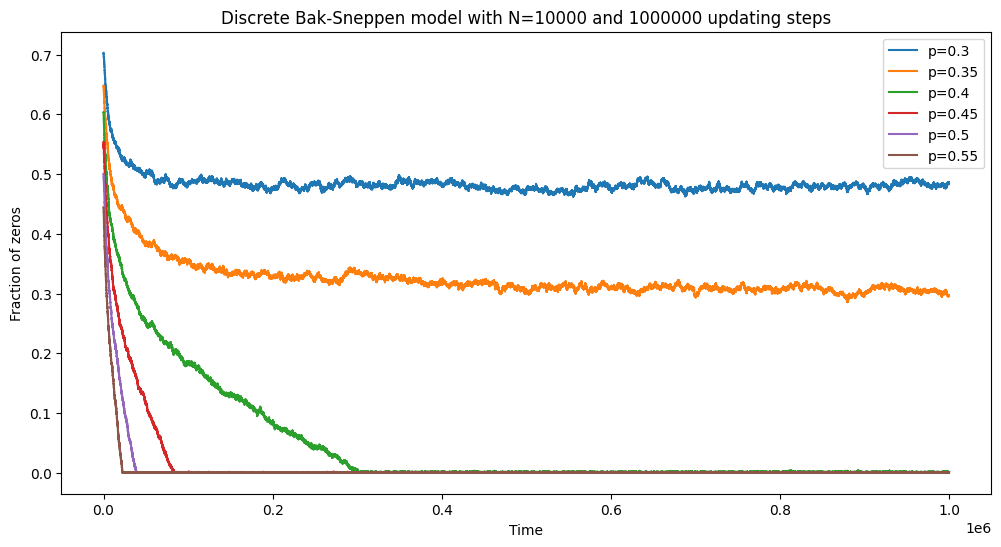

In [ ]:
# Repeated experiment for different bernoulli parameter values

p_vals = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55]

N = 10000
T = 1000000

burn_in = 20000

plt.figure(figsize=(12,6))

print(f"For N={N} and {T} updating steps:")

for p in p_vals:
    zero_density = DBS(N, p, T)

    plt.plot(zero_density, label=f"p={p}")

    stationary_density = np.mean(zero_density[burn_in:])
    print(f"Stationary density of zeros for p={p}: {stationary_density}")

print(f"For N={N} and {T} updating steps:")

plt.xlabel("Time")
plt.ylabel("Fraction of zeros")
plt.title("Discrete model dynamics")
plt.legend()
plt.show()

For N=100000 and 10000000 updating steps:
Stationary density of zeros for p=0.36: 0.2721864470540817
Stationary density of zeros for p=0.365: 0.24164022810408162
Stationary density of zeros for p=0.37: 0.2091739752255102
Stationary density of zeros for p=0.375: 0.1706278707489796
Stationary density of zeros for p=0.38: 0.12557868369081632


C:\Users\Dylan\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


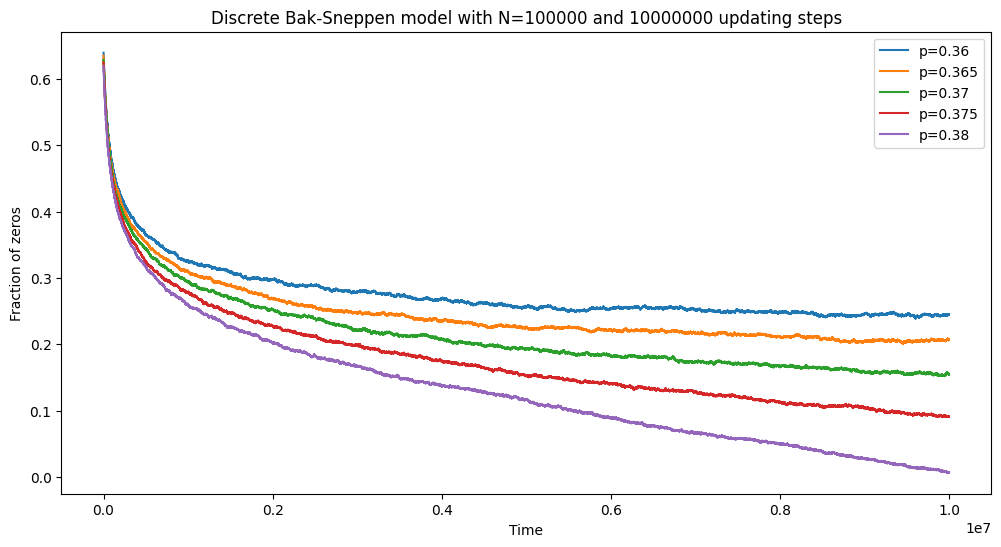

In [ ]:
# Repeated experiment for different bernoulli parameter values

p_val = [0.36, 0.365, 0.37, 0.375, 0.38]

N = 100000
T = 10000000

burn_in = 200000

plt.figure(figsize=(12,6))

print(f"For N={N} and {T} updating steps:")

for p in p_val:
    zero_density = DBS(N, p, T)

    plt.plot(zero_density, label=f"p={p}")

    stationary_density = np.mean(zero_density[burn_in:])
    print(f"Stationary density of zeros for p={p}: {stationary_density}")

plt.xlabel("Time")
plt.ylabel("Fraction of zeros")
plt.title("Discrete model dynamics")
plt.legend()
plt.show()